zany-darkness-314
comic-frog-309
fiery-durian-305
easy-wood-305
colorful-sound-308
fiery-wood-305
restful-eon-304
tough-oath-301
jolly-rain-302
clean-shadow-302
youthful-frost-297
azure-jazz-297
good-firefly-296
smart-haze-295
lucky-snow-290
lemon-glade-282
trim-donkey-280
unique-snowball-281
peach-plasma-273
prime-cosmos-273


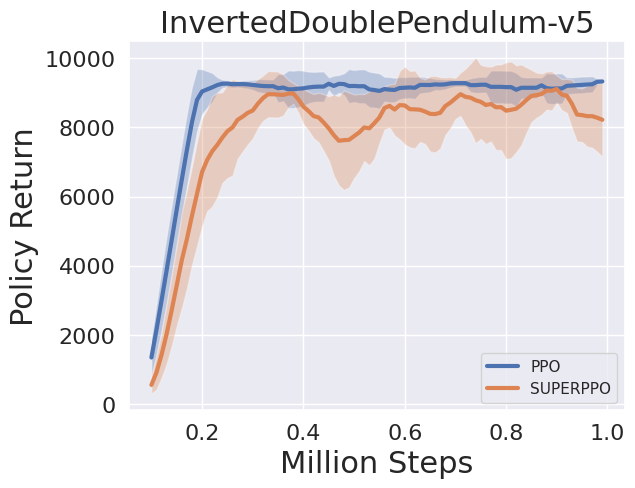

lemon-valley-401
rosy-sun-40
prime-serenity-39
solar-vortex-38
stellar-moon-36
wobbly-elevator-34
eager-glade-35
ethereal-sea-36
crimson-bee-33
crimson-sky-30
polished-forest-31
wobbly-firefly-174
magic-flower-173
gallant-sound-172
volcanic-frog-171
dandy-water-170
northern-universe-169
toasty-firefly-167
chocolate-voice-166
iconic-galaxy-161
avid-serenity-161


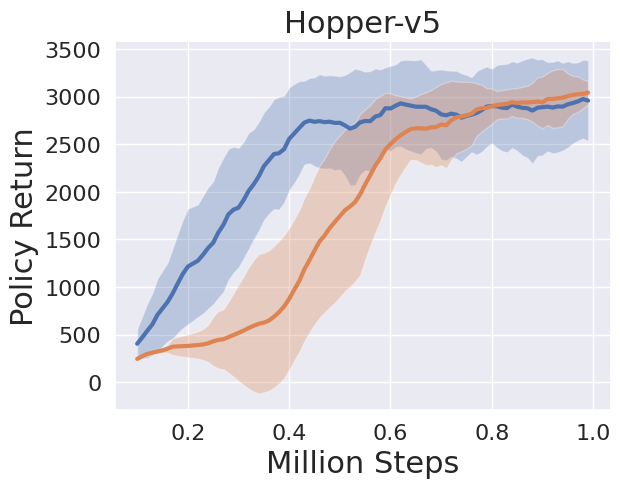

classic-morning-9
glorious-totem-10
brisk-dew-8
charmed-dawn-7
fresh-bee-5
gentle-lion-6
crisp-galaxy-1
polar-pond-4
faithful-thunder-1
glowing-puddle-1
hopeful-sea-168
dashing-gorge-164
classic-surf-164
graceful-sea-160
winter-star-159
vague-resonance-157
glowing-morning-157
wise-deluge-152
sleek-shadow-152
likely-armadillo-151


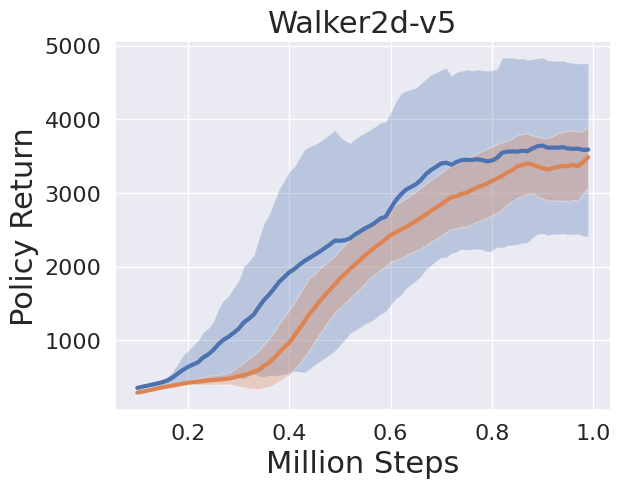

astral-cherry-411
glad-lake-408
playful-morning-408
glowing-leaf-406
ancient-sponge-402
ancient-voice-180
exalted-wildflower-179
fresh-elevator-178
easy-armadillo-177
spring-pine-176
worthy-tree-175
twilight-puddle-163
curious-shadow-155
iconic-pyramid-156
grateful-night-154


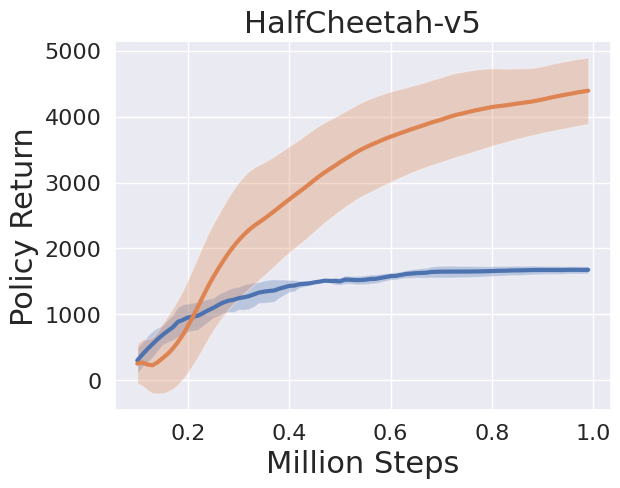

eager-dawn-410
eternal-fire-407
easy-salad-403
major-voice-403
electric-salad-403
silver-grass-190
worldly-frost-189
graceful-elevator-187
deep-serenity-188
sparkling-yogurt-186
genial-gorge-185
polished-plasma-184
fanciful-snow-183
honest-feather-181
devout-dream-182


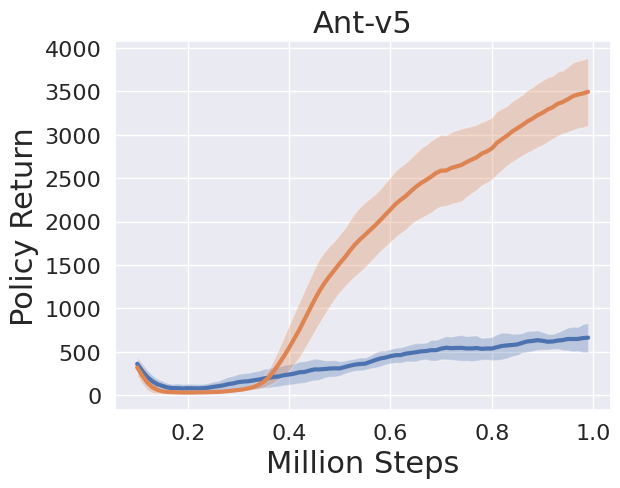

celestial-sea-110
sage-night-109
eager-dream-106
curious-silence-108
rare-sky-107
earthy-blaze-102
peach-smoke-102
polar-night-105
deft-water-102
graceful-energy-101
decent-lake-260
daily-glade-259
hardy-oath-258
hearty-cloud-257
earthy-violet-256
grateful-puddle-252
noble-bird-251
hardy-pine-249
polished-butterfly-249
lucky-flower-248


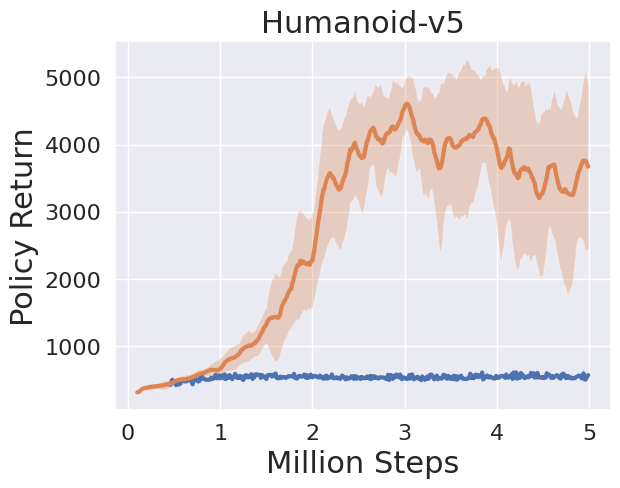

In [2]:
import pandas as pd
import wandb
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import itertools

sns.set(font_scale=1.3)
sns.set_theme()


os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
api = wandb.Api()
entity, project_99,project_995 = "mahdikallel", "iclr_close", "iclr_995_tunisia_constant_temp"
runs_99 = api.runs(entity + "/" + project_99)
runs_995 = api.runs(entity + "/" + project_995)

runs = itertools.chain(runs_99,runs_995)
#runs = runs_995

def filter_ppo(run,env_name,gamma,normalize_reward):
    return run.config["env_name"] == env_name and gamma == run.config["gamma"] and run.config["algo_name"] == "ppo" and normalize_reward == run.config["normalize_reward"]


def filter_superppo(run,env_name,gamma,discount_actor,on_policy_data,momentum):
    return run.config["env_name"] == env_name and run.config["algo_name"] == "superppo" and gamma == run.config["gamma"] and discount_actor == run.config["discount_actor"] and momentum == run.config["momentum"] and on_policy_data == run.config["on_policy_data"]



dc = {"ppo":{"normalize_reward":True,"gamma":0.99},"superppo":{"gamma":0.995,"on_policy_data":False,"discount_actor":True,"momentum":0.9}}
legends = [""]
env_names = ["InvertedDoublePendulum-v5","Hopper-v5","Walker2d-v5","HalfCheetah-v5","Ant-v5","Humanoid-v5"]
max_steps = [1e6,1e6,1e6,1e6,1e6,5e6]
legend = [True,False,False,False,False,False]

for env_name,max_step,legend in zip(env_names,max_steps,legend):


    algo_name = ["ppo","superppo"]
    for algo in algo_name:
            
            df = pd.DataFrame()
            config_list, name_list,run_list= [], [],[]
            for run in runs:
                
                
            
                # .config contains the hyperparameters.
                #  We remove special values that start with _.
                
                if "superppo" in algo:

                    if filter_superppo(run,env_name,**dc[algo]):
                        config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                        # .name is the human-readable name of the run.
                        name_list.append(run.name)
                        full_df = run.history(samples=10000)
                        tmp_df = full_df[['evaluation/undisc_policy_return','_step']].dropna(axis=0)
                        tmp_df["average return"] = tmp_df['evaluation/undisc_policy_return'].rolling(window=10).mean()
                        tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                        tmp_df = tmp_df[["step","average return"]]
                        df = pd.concat([df, tmp_df], ignore_index=True)
                        print(run.name)
                        

                elif "ppo" in algo :        
                    
                    if filter_ppo(run,env_name,**dc[algo]):
                        config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                        # .name is the human-readable name of the run.
                        name_list.append(run.name)
                        full_df = run.history(samples=10000)
                        tmp_df = full_df[['evaluation/undisc_policy_return','_step']].dropna(axis=0)
                        tmp_df["average return"] = tmp_df['evaluation/undisc_policy_return'].rolling(window=10).mean()
                        tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                        tmp_df = tmp_df[["step","average return"]]
                        df = pd.concat([df, tmp_df], ignore_index=True)
                        print(run.name)
                


            runs_df = pd.DataFrame({"config": config_list, "name": name_list})
            df = df[df["step"]<int(max_step)]
            x = df.groupby("step")["step"].mean()/1e6
            mean = df.groupby("step")["average return"].mean()
            #stderror = df.groupby("step")["average return"].std()/np.sqrt(df.groupby("step")["average return"].count())
            stderror = df.groupby("step")["average return"].std()

            plt.plot(x,mean,label=algo.upper(),linewidth=3)
            plt.fill_between(x,mean-stderror,mean+stderror, alpha=0.3)
            plt.xticks(fontsize=16)
            plt.yticks(fontsize=16)
            plt.xlabel('Million Steps',fontsize=22)
            plt.ylabel('Policy Return',fontsize=22)
            plt.title(env_name,fontsize=22)
            runs = itertools.chain(runs_99,runs_995)

    if legend : plt.legend()      
    #plt.savefig("./plots/delete/"+env_name+"_benchmark_995.pdf", format="pdf", bbox_inches="tight")  
    plt.show()

In [1]:
import pandas as pd
import wandb
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import itertools
import matplotlib

sns.set(font_scale=3.)
#matplotlib.rcParams.update({'font.size': 28})
sns.set_theme()

matplotlib.rcParams.update({'font.size': 50})



os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
api = wandb.Api()
entity, project_99,project_995 = "mahdikallel", "finishitto", "finishitto_995"

runs_995 = api.runs(entity + "/" + project_995)
#runs = itertools.chain(runs_99,runs_995,runs_onp)
runs = runs_995




env_name = "InvertedDoublePendulum-v5"

dc = {"TOP-PPO":{"gamma":0.995,"discount_actor":True,"momentum":0.,"on_policy_data":False},
      "-Discount PG":{"gamma":0.995,"discount_actor":False,"momentum":0.,"on_policy_data":False},
      "-Off policy":{"gamma":0.995,"discount_actor":True,"momentum":0.,"on_policy_data":True},
      "+Momentum":{"gamma":0.995,"discount_actor":True,"momentum":0.9,"on_policy_data":False},
      }
legends = [""]


env_names = ["InvertedDoublePendulum-v5","Hopper-v5","Walker2d-v5","HalfCheetah-v5","Ant-v5","Humanoid-v5"]
max_steps = [1e6,1e6,1e6,1e6,1e6,5e6]
legend = [True,False,False,False,False,False]

for env_name,max_step,legend in zip(env_names,max_steps,legend):


    
    algo_name = ["TOP-PPO","-Discount PG","-Off policy","+Momentum"]
    
    for algo in algo_name:
            
            df = pd.DataFrame()
            config_list, name_list,run_list= [], [],[]
            for run in runs:
            
                # .config contains the hyperparameters.
                #  We remove special values that start with _.
                
                if filter_superppo(run,env_name,**dc[algo]):
                    config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                    # .name is the human-readable name of the run.
                    name_list.append(run.name)
                    full_df = run.history(samples=10000)
                    tmp_df = full_df[['evaluation/episode.return','_step']].dropna(axis=0)
                    tmp_df["average return"] = tmp_df['evaluation/episode.return'].rolling(window=10).mean()
                    tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                    tmp_df = tmp_df[["step","average return"]]
                    df = pd.concat([df, tmp_df], ignore_index=True)
                    print(run.name)

            


            runs_df = pd.DataFrame({"config": config_list, "name": name_list})
            df = df[df["step"]<int(max_step)]
            x = df.groupby("step")["step"].mean()/1e6
            mean = df.groupby("step")["average return"].mean()
            #stderror = df.groupby("step")["average return"].std()/np.sqrt(df.groupby("step")["average return"].count())
            stderror = df.groupby("step")["average return"].std()
            
            #plt.axis('equal')
            plt.plot(x,mean,label=algo.upper(),linewidth=3)
            plt.fill_between(x,mean-stderror,mean+stderror, alpha=0.3)
            plt.xticks(fontsize=16)
            plt.yticks(fontsize=16)
            plt.xlabel('Million Steps',fontsize=22)
            plt.ylabel('Average Return',fontsize=22)
            plt.title(env_name,fontsize=22)
            #runs = itertools.chain(runs_99,runs_995)
            runs = itertools.chain(runs_99,runs_995)

    if legend : plt.legend()      
    plt.savefig("./plots/ablations_995/"+env_name+"_ablation_995.pdf", format="pdf", bbox_inches="tight")  
    plt.show()


NameError: name 'filter_superppo' is not defined

In [ ]:
import matplotlib.pyplot as plt
items= ["chocolate", "toffees", "cake", "colddrinks", "lays", "biscuit", "frooti"]
sales =[89000, 25000, 98777, 12000, 65000, 11100, 96000]
plt.plot(items,sales,color='m')
a=plt.gca()
plt.xlabel("ITEMS")
plt.ylabel("SALES")
plt.suptitle("SHOP MANGEMENT", fontsize =15)
plt.show()